In [21]:
from rdkit.Chem import AllChem as Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns
import numpy as np

from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw

from rdkit import DataStructs

from sklearn import metrics
import numpy

from sklearn.manifold import TSNE
from rdkit.SimDivFilters import rdSimDivPickers

In [2]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)
#drugbank_df

In [3]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)
#zinc_df

In [4]:
mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)
#mtor_df

In [5]:
structures = pd.concat([drugbank_df, zinc_df, mtor_df])

In [6]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=1024)
structures["ECFP6"] = structures["mol"].apply(morgan_gen.GetFingerprint)

In [7]:
structures["explicit_bits"] = structures["mol"].apply(morgan_gen.GetFingerprintAsNumPy)

In [9]:
fps = numpy.array(structures["explicit_bits"].to_list())

In [14]:
tsne = TSNE(n_jobs=-1)

In [15]:
dims = tsne.fit_transform(fps)

In [17]:
dims

array([[ 11.845649, -62.292377],
       [ 13.480247, -63.89903 ],
       [ 13.248928, -60.559788],
       ...,
       [-35.711166,  -4.213742],
       [-83.614944,  47.66999 ],
       [-41.308792,   8.212097]], shape=(18896, 2), dtype=float32)

In [26]:
# zinc = structures[structures["source"]=="zinc"]
def dist_fce(x,y):
    return 1-DataStructs.TanimotoSimilarity(
        structures.iloc[x]["ECFP6"],
        structures.iloc[y]["ECFP6"]
    )

In [27]:
picker = rdSimDivPickers.MaxMinPicker()
picked = picker.LazyPick(dist_fce, len(structures), 500)

In [30]:
spicked = set(picked)
structures["picked"] = [x in spicked for x in range(len(structures))]

In [36]:
structures["tsne1"] = [x[0] for x in dims]
structures["tsne2"] = [x[1] for x in dims]

<Axes: xlabel='tsne1', ylabel='tsne2'>

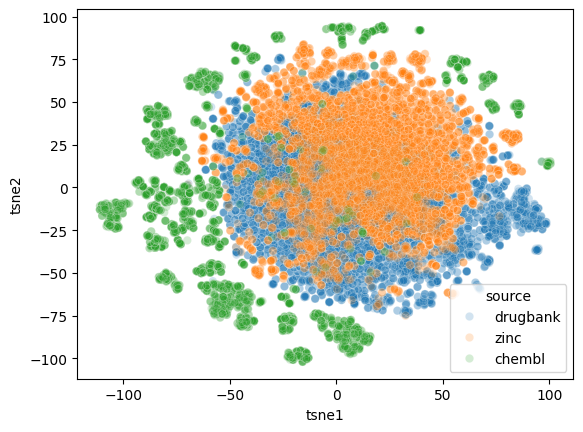

In [39]:
sns.scatterplot(data=structures, x="tsne1", y="tsne2", hue="source", alpha=0.2)

<Axes: xlabel='tsne1', ylabel='tsne2'>

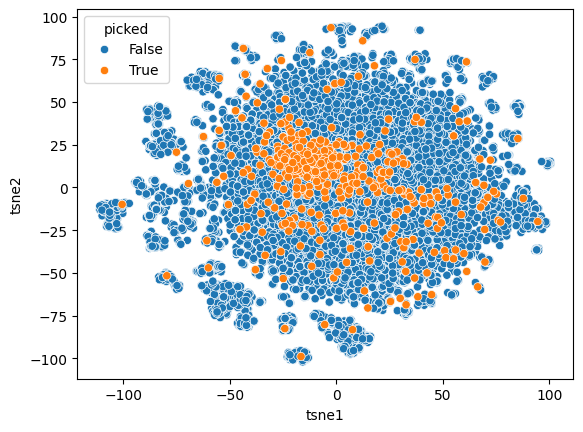

In [41]:
sns.scatterplot(data=structures.sort_values("picked"), x="tsne1", y="tsne2", hue="picked")

In [43]:
structures.to_csv(path_or_buf="../data/structures_tsne.csv")